<a href="https://colab.research.google.com/github/Riz2693/Higo-Technical-Test/blob/main/2.%20Analisis%20Dan%20EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import Library Yang Digunakan**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import iqr

# **Load dataset**

In [ ]:
df = pd.read_csv('/content/data_dummy_pengguna.csv')
df.head(5)

,Nama Lokasi,Tipe Lokasi,Jam Login,Nama,Email,No Telepon,Tahun Lahir,Merk HP,Minat Digital,CTR,Durasi Akses (Menit/Minggu),Skor CTR,Skor Durasi Akses (Menit/Minggu),Skor Minat Digital,Level Respons CTR,Level Durasi Akses,Level Minat Digital,Usia,Sesi Login
0,Kopi Kenangan Senayan,Cafe,00:47:17,"Balidin Dongoran, S.T.",ivanmandala@hotmail.com,+62 (081) 960-0133,1987,Apple,F&B & Culinary Lifestyle,11.0,149,73.333333,24.833333,49.1,Tinggi,Rendah,Sedang,39,Malam
1,Stasiun Sudirman,Transportasi,13:02:01,Drs. Akarsana Purwanti,salsabilapalastri@yahoo.com,+62-0794-026-5423,1982,Apple,F&B & Culinary Lifestyle,7.6,87,50.666667,14.500000,32.6,Sedang,Rendah,Rendah,44,Siang
2,Stasiun Sudirman,Transportasi,06:45:41,"Tgk. Baktiono Iswahyudi, S.Sos",tambamalik@hotmail.com,+62 (0078) 161 8495,2002,Vivo,Entertainment & Streaming,3.3,344,22.000000,57.333333,39.7,Rendah,Sedang,Rendah,24,Pagi
3,Kopi Kenangan Senayan,Cafe,05:44:27,R.A. Tiara Hidayat,wijayantijaga@yahoo.com,+62 (031) 647 5255,1990,Xiaomi,F&B & Culinary Lifestyle,3.2,404,21.333333,67.333333,44.3,Rendah,Sedang,Sedang,36,Pagi
4,Kopi Kenangan Senayan,Cafe,02:24:06,Mumpuni Santoso,sudiatirahmi@gmail.com,0832764835,1991,Xiaomi,Travel & Leisure,4.0,104,26.666667,17.333333,22.0,Rendah,Rendah,Rendah,35,Malam


# **Cek Informasi Dataset**

In [ ]:
# Cek type data dan jumlah kolom pada dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Nama Lokasi                       1000 non-null   object 
 1   Tipe Lokasi                       1000 non-null   object 
 2   Jam Login                         1000 non-null   object 
 3   Nama                              1000 non-null   object 
 4   Email                             1000 non-null   object 
 5   No Telepon                        1000 non-null   object 
 6   Tahun Lahir                       1000 non-null   int64  
 7   Merk HP                           1000 non-null   object 
 8   Minat Digital                     1000 non-null   object 
 9   CTR                               1000 non-null   float64
 10  Durasi Akses (Menit/Minggu)       1000 non-null   int64  
 11  Skor CTR                          1000 non-null   float64
 12  Skor Du

In [ ]:
# Cek informasi numerik pada dataset
df.describe()

,Tahun Lahir,CTR,Durasi Akses (Menit/Minggu),Skor CTR,Skor Durasi Akses (Menit/Minggu),Skor Minat Digital,Usia
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,1994.490000,7.344600,335.182000,48.964000,55.863667,52.413500,31.510000
std,8.466025,4.286949,154.665459,28.579658,25.777577,19.169935,8.466025
min,1980.000000,0.000000,62.000000,0.000000,10.333333,6.500000,18.000000
25%,1987.000000,3.600000,198.000000,24.000000,33.000000,38.450000,24.000000
50%,1995.000000,7.300000,340.000000,48.666667,56.666667,52.100000,31.000000
75%,2002.000000,10.800000,470.750000,72.000000,78.458333,65.450000,39.000000
max,2008.000000,15.000000,599.000000,100.000000,99.833333,99.300000,46.000000


# **Drop beberapa kolom yang tidak digunakan untuk mempermudah EDA**

In [ ]:
# Drop kolom jam login dan tahun lahir karena sudah terdapat kolom hasil ekstraksi nya
df.drop(['Jam Login', 'Tahun Lahir'], inplace=True, axis=1)
df.head(5)

,Nama Lokasi,Tipe Lokasi,Nama,Email,No Telepon,Merk HP,Minat Digital,CTR,Durasi Akses (Menit/Minggu),Skor CTR,Skor Durasi Akses (Menit/Minggu),Skor Minat Digital,Level Respons CTR,Level Durasi Akses,Level Minat Digital,Usia,Sesi Login
0,Kopi Kenangan Senayan,Cafe,"Balidin Dongoran, S.T.",ivanmandala@hotmail.com,+62 (081) 960-0133,Apple,F&B & Culinary Lifestyle,11.0,149,73.333333,24.833333,49.1,Tinggi,Rendah,Sedang,39,Malam
1,Stasiun Sudirman,Transportasi,Drs. Akarsana Purwanti,salsabilapalastri@yahoo.com,+62-0794-026-5423,Apple,F&B & Culinary Lifestyle,7.6,87,50.666667,14.500000,32.6,Sedang,Rendah,Rendah,44,Siang
2,Stasiun Sudirman,Transportasi,"Tgk. Baktiono Iswahyudi, S.Sos",tambamalik@hotmail.com,+62 (0078) 161 8495,Vivo,Entertainment & Streaming,3.3,344,22.000000,57.333333,39.7,Rendah,Sedang,Rendah,24,Pagi
3,Kopi Kenangan Senayan,Cafe,R.A. Tiara Hidayat,wijayantijaga@yahoo.com,+62 (031) 647 5255,Xiaomi,F&B & Culinary Lifestyle,3.2,404,21.333333,67.333333,44.3,Rendah,Sedang,Sedang,36,Pagi
4,Kopi Kenangan Senayan,Cafe,Mumpuni Santoso,sudiatirahmi@gmail.com,0832764835,Xiaomi,Travel & Leisure,4.0,104,26.666667,17.333333,22.0,Rendah,Rendah,Rendah,35,Malam


In [ ]:
# Drop kolom nama, email dan nomor telp karena mengandung informasi privat
df.drop(['Nama', 'Email', 'No Telepon'], inplace=True, axis=1)
df.head(5)

,Nama Lokasi,Tipe Lokasi,Merk HP,Minat Digital,CTR,Durasi Akses (Menit/Minggu),Skor CTR,Skor Durasi Akses (Menit/Minggu),Skor Minat Digital,Level Respons CTR,Level Durasi Akses,Level Minat Digital,Usia,Sesi Login
0,Kopi Kenangan Senayan,Cafe,Apple,F&B & Culinary Lifestyle,11.0,149,73.333333,24.833333,49.1,Tinggi,Rendah,Sedang,39,Malam
1,Stasiun Sudirman,Transportasi,Apple,F&B & Culinary Lifestyle,7.6,87,50.666667,14.500000,32.6,Sedang,Rendah,Rendah,44,Siang
2,Stasiun Sudirman,Transportasi,Vivo,Entertainment & Streaming,3.3,344,22.000000,57.333333,39.7,Rendah,Sedang,Rendah,24,Pagi
3,Kopi Kenangan Senayan,Cafe,Xiaomi,F&B & Culinary Lifestyle,3.2,404,21.333333,67.333333,44.3,Rendah,Sedang,Sedang,36,Pagi
4,Kopi Kenangan Senayan,Cafe,Xiaomi,Travel & Leisure,4.0,104,26.666667,17.333333,22.0,Rendah,Rendah,Rendah,35,Malam


# **Cek kebersihan dan konsistensi dataset**

## **Function helper untuk membantu dalam pengecekan dataset**

In [ ]:
def cek_nan(data):
  """
  Function yang digunakan untuk memeriksa nilai nan dari data
  input   : data
  output  : nan_info (DataFrame)
  return  : nan_info (DataFrame)
  """
  nan_info = pd.DataFrame(data.isna().sum().sort_values(ascending=False), columns=['Jumlah Nilai Missing'])

  if nan_info['Jumlah Nilai Missing'].sum() == 0:
    print("Tidak ada nilai missing")
    return None
  else:
    nan_info['Persentase Nilai Missing (%)'] = ((nan_info['Jumlah Nilai Missing'] / len(data)) * 100).round(3)

    # return data dengan nilai missing, apabila ingin mereturn keseluruhan data maka ubah menjadi return nan_info
    return nan_info[nan_info['Jumlah Nilai Missing'] > 0]


def visualize_row_with_nan(data, method='all', columns=None):
  """
  Procedure yang digunakan untuk menvisualisasikan baris yang mengandung NaN berdasarkan metode yang dipilih
  input   : data, method, columns
  output  : baris_nan (DataFrame)
  """
  try:
    if method not in ['all', 'column', 'columns']:
      raise ValueError("Metode tidak valid. Pilih salah satu dari 'all', 'column', 'columns'.")

    if method == 'all':
      display(data[data.isna().any(axis=1)])

    elif method == 'column':
      if not isinstance(columns, str):
          raise TypeError("Untuk metode 'column', argumen 'columns' harus berupa String.")
      if columns not in data.columns:
          raise KeyError(f"Kolom '{columns}' tidak ditemukan dalam DataFrame.")
      display(data[data[columns].isna()])

    elif method == 'columns':
      if not isinstance(columns, list):
          raise TypeError("Untuk metode 'columns', argumen 'columns' harus berupa list.")
      for column in columns:
          if column not in data.columns:
              raise KeyError(f"Kolom '{column}' tidak ditemukan dalam DataFrame.")
      display(data[data[columns].isna().all(axis=1)])

  except (TypeError, KeyError) as e:
    print(f"Kesalahan dalam memproses data: {e}")


def visualize_row_with_duplicated(data):
  """
  Procedure yang digunakan untuk menvisualisasikan baris yang mengandung data duplikat
  input   : data
  output  : baris_duplikat (DataFrame)
  """
  duplicated = data.duplicated().sum()

  if duplicated > 0:
    print("Jumlah Data Duplikat :", duplicated)
    all_duplicates = data[data.duplicated(keep=False)]

    duplicate_indices = all_duplicates.groupby(list(all_duplicates.columns)).groups
    print("Pasangan Data Duplikat :")
    for group_indices in duplicate_indices.values():
      if len(group_indices) > 1:
        display(data.iloc[list(group_indices)])
        print("\n")
  else:
    print("Tidak ada data duplikat")


def get_bounds(data):
  """
  Function helper yang digunakan untuk mendapatkan batas bawah dan batas atas dari data
  input   : data
  output  : lower, upper
  return  : lower, upper
  """
  q1 = data.quantile(0.25)
  q3 = data.quantile(0.75)
  # nan_policy omit digunakan untuk ignore nilai NaN, sehingga perhitungan outlier tidak terganggu oleh nilai NaN
  IQR = iqr(data, nan_policy='omit')

  lower = q1 - 1.5 * IQR
  upper = q3 + 1.5 * IQR

  return lower, upper


def get_outlier(data, lower, upper, columns=None):
  """
  Function helper untuk mendapatkan outlier dari data
  input   : data, lower, upper, columns
  output  : outliers (DataFrame)
  return  : outliers (DataFrame)
  """
  return data[(data[columns] < lower) | (data[columns] > upper)]


def cek_outlier_iqr(data, method='all', columns=None):
  """
  Function untuk memeriksa outlier menggunakan metode IQR
  input   : data, method, columns
  output  : outliers (DataFrame)
  return  : column outlier (Array)
  """
  try:
    # column_outlier = []

    if method not in ['all', 'column', 'columns']:
      raise ValueError("Metode tidak valid. Pilih salah satu dari 'all', 'column', 'columns'.")

    if method == 'all':
      for column in data.select_dtypes(include=np.number).columns:
        lower, upper = get_bounds(data[column])
        outliers = get_outlier(data, lower, upper, column)

        if not outliers.empty:
          print(f"Outliers pada kolom {column}:")
          display(outliers[column].unique())
          print(f"Jumlah Outliers: {outliers[column].shape[0]}")
          print("\n")
          # column_outlier.append(column)

      if outliers.empty:
        print(f"Tidak ada outlier pada data")

    elif method == 'column':
      if not isinstance(columns, str):
        raise TypeError("Untuk metode 'column', argumen 'columns' harus berupa String.")
      if columns not in data.columns:
        raise KeyError(f"Kolom '{columns}' tidak ditemukan dalam DataFrame.")
      if not np.issubdtype(data[columns].dtype, np.number):
        raise TypeError(f"Kolom '{columns}' bukan tipe numerik.")
      lower, upper = get_bounds(data[columns])
      outliers = get_outlier(data, lower, upper, columns)

      if not outliers.empty:
        print(f"Outliers pada kolom {columns}:")
        display(outliers[columns].unique())
        print(f"Jumlah Outliers: {outliers[columns].shape[0]}")
        print("\n")
        # column_outlier.append(columns)

      else:
        print(f"Tidak ada outlier pada kolom {columns}")

    elif method == 'columns':
      if not isinstance(columns, list):
        raise TypeError("Untuk metode 'columns', argumen 'columns' harus berupa list.")
      for column in columns:
        if column not in data.columns:
          raise KeyError(f"Kolom '{column}' tidak ditemukan dalam DataFrame.")
        if not np.issubdtype(data[column].dtype, np.number):
          raise TypeError(f"Kolom '{column}' bukan tipe numerik.")

        lower, upper = get_bounds(data[column])
        outliers = get_outlier(data, lower, upper, column)

        if not outliers.empty:
          print(f"Outliers pada kolom {column}:")
          display(outliers[column].unique())
          print(f"Jumlah Outliers: {outliers[column].shape[0]}")
          print("\n")
          # column_outlier.append(columns)

        else:
          print(f"Tidak ada outlier pada kolom {column}")

  except (TypeError, KeyError) as e:
    print(f"Kesalahan dalam memproses data: {e}")

  # return column_outlier


def filter_outlier_method(data, lower, upper, method='capping', column=None):
  """
  Function helper untuk menfilter data berdasarkan batas bawah dan batas atas
  input   : data, lower, upper, method, columns
  output  : filtered_data (DataFrame)
  return  : filtered_data (DataFrame)
  """
  # Type conversion is now handled in filter_outliers_iqr to avoid redundant checks
  # and potential SettingWithCopyWarning issues when `data` is a view.

  if method == "nan":  # ubah outlier → NaN
    data.loc[(data[column] < lower) | (data[column] > upper), column] = np.nan
  elif method == "drop":  # hapus baris dengan outlier
    data = data[(data[column] >= lower) & (data[column] <= upper)]
  elif method == "capping":
    data.loc[data[column] < lower, column] = lower
    data.loc[data[column] > upper, column] = upper

  return data


def filter_outliers_iqr(data, filter_method="capping", column_method="all", columns=None):
  """
  Procedure untuk menfilter outlier menggunakan metode IQR
  input   : data, filter_method, column_method, columns
  output  : filtered data (DataFrame)
  return  : filtered data (DataFrame)
  """
  try:
    if filter_method not in ['nan', 'drop', 'capping']:
      raise ValueError("Metode tidak valid. Pilih salah satu dari 'nan', 'drop', 'capping'.")
    if column_method not in ['all', 'column', 'columns']:
      raise ValueError("Metode tidak valid. Pilih salah satu dari 'all', 'column', 'columns'.")

    # Create a copy to avoid modifying the original DataFrame in place when changing dtypes
    # and to ensure consistent type handling throughout the capping process.
    df_processed = data.copy()

    if column_method == 'all':
      for column in df_processed.select_dtypes(include=np.number).columns:
        # if pd.api.types.is_integer_dtype(df_processed[column]):
        #     df_processed[column] = df_processed[column].astype(float)
        lower, upper = get_bounds(df_processed[column])
        df_processed = filter_outlier_method(df_processed, lower, upper, filter_method, column)

    elif column_method == 'column':
      if not isinstance(columns, str):
          raise TypeError("Untuk metode 'column', argumen 'columns' harus berupa String.")
      if columns not in df_processed.columns:
          raise KeyError(f"Kolom '{columns}' tidak ditemukan dalam DataFrame.")
      if not np.issubdtype(df_processed[columns].dtype, np.number):
          raise TypeError(f"Kolom '{columns}' bukan tipe numerik.")
      # if pd.api.types.is_integer_dtype(df_processed[columns]):
      #     df_processed[columns] = df_processed[columns].astype(float)
      lower, upper = get_bounds(df_processed[columns])
      df_processed = filter_outlier_method(df_processed, lower, upper, filter_method, columns)

    elif column_method == 'columns':
      if not isinstance(columns, list):
        raise TypeError("Untuk metode 'columns', argumen 'columns' harus berupa list.")
      for column in columns:
        if column not in df_processed.columns:
          raise KeyError(f"Kolom '{column}' tidak ditemukan dalam DataFrame.")
        if not np.issubdtype(df_processed[column].dtype, np.number):
          raise TypeError(f"Kolom '{column}' bukan tipe numerik.")
        # if pd.api.types.is_integer_dtype(df_processed[column]):
        #     df_processed[column] = df_processed[column].astype(float)
        lower, upper = get_bounds(df_processed[column])
        df_processed = filter_outlier_method(df_processed, lower, upper, filter_method, column)

  except (ValueError, TypeError, KeyError) as e:
    print(f"Kesalahan dalam memproses data: {e}")
  return df_processed

In [ ]:
# Cek nilai kosong pada dataset
cek_nan(df)

,Jumlah Nilai Missing,Persentase Nilai Missing (%)
Level Respons CTR,1,0.1


In [ ]:
# Cek duplikasi data pada dataset
visualize_row_with_duplicated(df)

Tidak ada data duplikat


In [ ]:
# Cek outlier pada dataset
cek_outlier_iqr(df)

Tidak ada outlier pada data


In [ ]:
# Tampilkan kolom akhir setelah pengecekan
df.head(5)

,Nama Lokasi,Tipe Lokasi,Merk HP,Minat Digital,CTR,Durasi Akses (Menit/Minggu),Skor CTR,Skor Durasi Akses (Menit/Minggu),Skor Minat Digital,Level Respons CTR,Level Durasi Akses,Level Minat Digital,Usia,Sesi Login
0,Kopi Kenangan Senayan,Cafe,Apple,F&B & Culinary Lifestyle,11.0,149,73.333333,24.833333,49.1,Tinggi,Rendah,Sedang,39,Malam
1,Stasiun Sudirman,Transportasi,Apple,F&B & Culinary Lifestyle,7.6,87,50.666667,14.500000,32.6,Sedang,Rendah,Rendah,44,Siang
2,Stasiun Sudirman,Transportasi,Vivo,Entertainment & Streaming,3.3,344,22.000000,57.333333,39.7,Rendah,Sedang,Rendah,24,Pagi
3,Kopi Kenangan Senayan,Cafe,Xiaomi,F&B & Culinary Lifestyle,3.2,404,21.333333,67.333333,44.3,Rendah,Sedang,Sedang,36,Pagi
4,Kopi Kenangan Senayan,Cafe,Xiaomi,Travel & Leisure,4.0,104,26.666667,17.333333,22.0,Rendah,Rendah,Rendah,35,Malam


# **Eksploratory data analysis (EDA)**

## **Jumlah merk HP yang mengakses layanan**

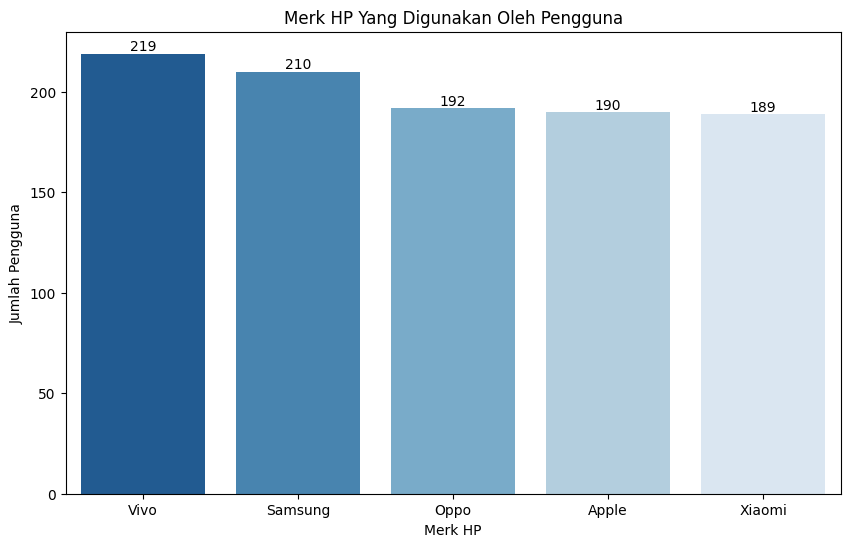

In [ ]:
count_merk_hp = df['Merk HP'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=count_merk_hp.index, y=count_merk_hp, palette='Blues_r', hue=count_merk_hp.index, legend=False)
plt.xlabel('Merk HP')
plt.ylabel('Jumlah Pengguna')
plt.title('Merk HP Yang Digunakan Oleh Pengguna')
plt.bar_label(plt.gca().containers[0])
plt.bar_label(plt.gca().containers[1])
plt.bar_label(plt.gca().containers[2])
plt.bar_label(plt.gca().containers[3])
plt.bar_label(plt.gca().containers[4])
plt.show()

## **Jumlah preferensi minat digital**

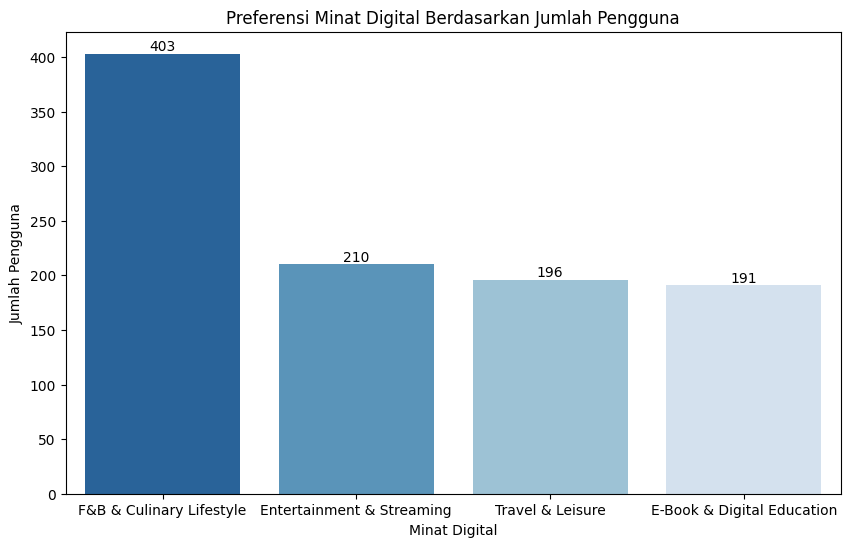

In [ ]:
count_minat = df['Minat Digital'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=count_minat.index, y=count_minat, palette='Blues_r', hue=count_minat.index, legend=False)
plt.xlabel('Minat Digital')
plt.ylabel('Jumlah Pengguna')
plt.title('Preferensi Minat Digital Berdasarkan Jumlah Pengguna')
plt.bar_label(plt.gca().containers[0])
plt.bar_label(plt.gca().containers[1])
plt.bar_label(plt.gca().containers[2])
plt.bar_label(plt.gca().containers[3])
plt.show()

## **Tipe lokasi terbanyak pengakses layanan**

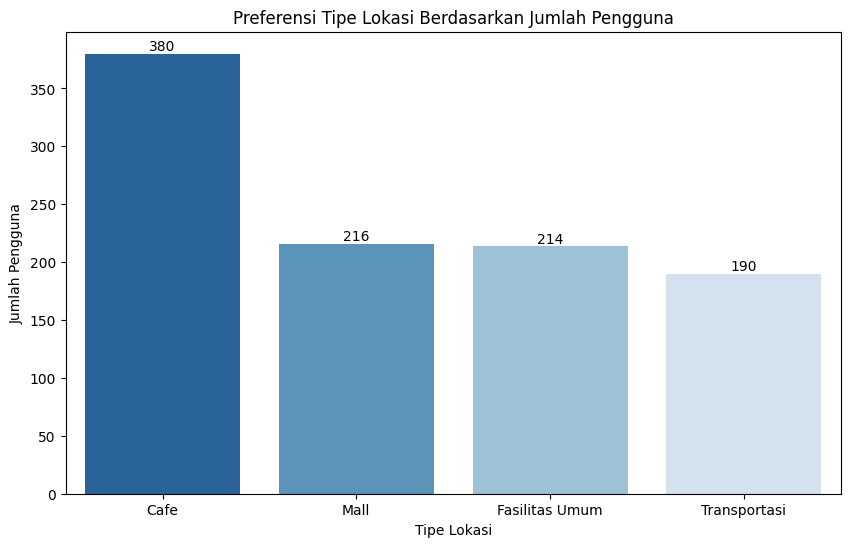

In [ ]:
count_tipe_lokasi = df['Tipe Lokasi'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=count_tipe_lokasi.index, y=count_tipe_lokasi, palette='Blues_r', hue=count_tipe_lokasi.index, legend=False)
plt.xlabel('Tipe Lokasi')
plt.ylabel('Jumlah Pengguna')
plt.title('Preferensi Tipe Lokasi Berdasarkan Jumlah Pengguna')
plt.bar_label(plt.gca().containers[0])
plt.bar_label(plt.gca().containers[1])
plt.bar_label(plt.gca().containers[2])
plt.bar_label(plt.gca().containers[3])
plt.show()

## **Lokasi terbanyak pengakses layanan**

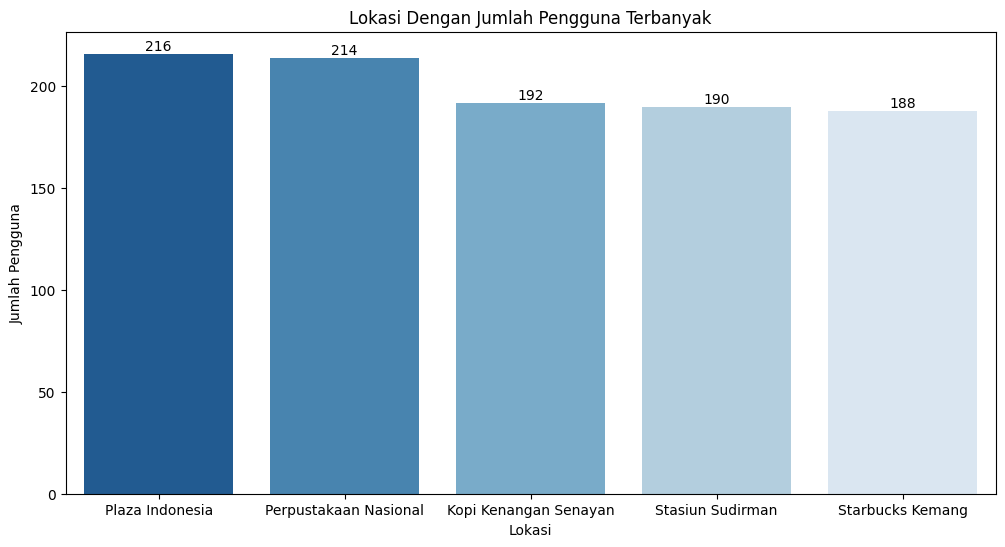

In [ ]:
count_nama_lokasi = df['Nama Lokasi'].value_counts()

plt.figure(figsize=(12, 6))
sns.barplot(x=count_nama_lokasi.index, y=count_nama_lokasi, palette='Blues_r', hue=count_nama_lokasi.index, legend=False)
plt.xlabel('Lokasi')
plt.ylabel('Jumlah Pengguna')
plt.title('Lokasi Dengan Jumlah Pengguna Terbanyak')
plt.bar_label(plt.gca().containers[0])
plt.bar_label(plt.gca().containers[1])
plt.bar_label(plt.gca().containers[2])
plt.bar_label(plt.gca().containers[3])
plt.bar_label(plt.gca().containers[4])
plt.show()